### **Analysis of Forest Land Diversion Projects**

**Problem Statement**

Forest land diversion for developmental projects has increased over the years, creating challenges in balancing infrastructure development and environmental conservation. This project aims to analyze forest diversion patterns across states, project categories, land types, and years to identify regions and sectors contributing most to forest land diversion and to understand trends in forest resource utilization.

**Key Questions Addressed**
- Which state has the highest number of forest diversion projects?
- Which state diverted the maximum forest land area?
- What are the top 10 states by diverted land area?
- What is the distribution of diverted land area across projects?
- What is the average diverted area per state?
- How does forest diversion vary across land types (RF, PF, Unclassified Forest)?
- Which year recorded the maximum number of projects?
- What is the typical project completion duration?

In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("D:/Entri DA/Python Main Project/Diverted Land_Sample_Data.csv")
print(df)


    State Name (state_name)  State Code (state_code)  \
0               Uttarakhand                        5   
1            Madhya Pradesh                       23   
2          Himachal Pradesh                        2   
3            Madhya Pradesh                       23   
4                   Haryana                        6   
..                      ...                      ...   
495             Uttarakhand                        5   
496        Himachal Pradesh                        2   
497          Andhra Pradesh                       28   
498                  Punjab                        3   
499           Uttar Pradesh                        9   

        Forest division name (division) Forest range name (range)  \
0                   DFO Almora , Almora       RO Ranikhet ,Almora   
1                     Balaghat North(T)               South Lamta   
2                                 Kullu                    Bhutti   
3                     Balaghat North(T)            

In [4]:
df.shape

(500, 13)

In [5]:
df.columns

Index(['State Name (state_name)', 'State Code (state_code)',
       'Forest division name (division)', 'Forest range name (range)',
       'Forest Conservation Act project (fca_project)',
       'Year of initiation of project (fca_project_year)',
       'Name of the site (site_name)',
       'Area diverted in hectares (area_diverted)', 'Type of land (land_type)',
       'Updated on (updated_on)', 'Updated by (updated_by)',
       'Diverted land GPS identifier (diverted_land_gps_id)', 'Unnamed: 12'],
      dtype='object')

In [6]:
df.dtypes

State Name (state_name)                                 object
State Code (state_code)                                  int64
Forest division name (division)                         object
Forest range name (range)                               object
Forest Conservation Act project (fca_project)           object
Year of initiation of project (fca_project_year)         int64
Name of the site (site_name)                            object
Area diverted in hectares (area_diverted)               object
Type of land (land_type)                                object
Updated on (updated_on)                                 object
Updated by (updated_by)                                 object
Diverted land GPS identifier (diverted_land_gps_id)     object
Unnamed: 12                                            float64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   State Name (state_name)                              500 non-null    object 
 1   State Code (state_code)                              500 non-null    int64  
 2   Forest division name (division)                      500 non-null    object 
 3   Forest range name (range)                            500 non-null    object 
 4   Forest Conservation Act project (fca_project)        500 non-null    object 
 5   Year of initiation of project (fca_project_year)     500 non-null    int64  
 6   Name of the site (site_name)                         499 non-null    object 
 7   Area diverted in hectares (area_diverted)            500 non-null    object 
 8   Type of land (land_type)                             500 non-null    o

In [8]:
df.duplicated().sum()
df.isnull().sum()

State Name (state_name)                                  0
State Code (state_code)                                  0
Forest division name (division)                          0
Forest range name (range)                                0
Forest Conservation Act project (fca_project)            0
Year of initiation of project (fca_project_year)         0
Name of the site (site_name)                             1
Area diverted in hectares (area_diverted)                0
Type of land (land_type)                                 0
Updated on (updated_on)                                  0
Updated by (updated_by)                                  0
Diverted land GPS identifier (diverted_land_gps_id)      0
Unnamed: 12                                            499
dtype: int64

In [9]:
df['Name of the site (site_name)'] = df['Name of the site (site_name)'].fillna('Unknown')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   State Name (state_name)                              500 non-null    object 
 1   State Code (state_code)                              500 non-null    int64  
 2   Forest division name (division)                      500 non-null    object 
 3   Forest range name (range)                            500 non-null    object 
 4   Forest Conservation Act project (fca_project)        500 non-null    object 
 5   Year of initiation of project (fca_project_year)     500 non-null    int64  
 6   Name of the site (site_name)                         500 non-null    object 
 7   Area diverted in hectares (area_diverted)            500 non-null    object 
 8   Type of land (land_type)                             500 non-null    o

In [11]:
df.columns=df.columns.str.replace(r'\s*\(.*', '', regex=True)


In [12]:
df.drop(columns=['Name of the site','Diverted land GPS identifier'], inplace=True)


In [13]:
df.drop(columns=['State Code'], inplace=True)


In [14]:
def text_cleaning(text):
    if not isinstance(text,str):# If input is not a string (int, float, None, etc.), return it unchanged
        return text
        
    if ',' in text:
        before,after = text.split(',',1)
        
        if after.strip().lower() in before.lower():
            return before.strip()
    return text.strip()
    

In [15]:
df['Forest division name']=df['Forest division name'].apply(text_cleaning)


In [16]:
df['Forest division name'].tail(10)

490                            Hoshiarpur
491                                 Surat
492                                Dasuya
493                               Kaithal
494                                  Manu
495               DFO Lansdowne, kotdwaar
496                         Ani at Luhari
497                              Kakinada
498                              Ludhiana
499    Social Forestry Division Moradabad
Name: Forest division name, dtype: object

In [17]:
df['Forest division name'] = df['Forest division name'].str.replace(r'\(T\)', '', regex=True).str.strip()


In [18]:
df['Forest division name'] = df['Forest division name'].str.replace('DFO , Nanda Devi national park','DFO Nanda Devi national park')

In [19]:
df['Forest division name']=df['Forest division name'].str.replace(',','')

In [20]:
df.columns=[col.capitalize() for col in df.columns]

In [21]:
df['Forest division name'].str.capitalize()


0                              Dfo almora
1                          Balaghat north
2                                   Kullu
3                          Balaghat north
4                                 Sonipat
                      ...                
495                Dfo lansdowne kotdwaar
496                         Ani at luhari
497                              Kakinada
498                              Ludhiana
499    Social forestry division moradabad
Name: Forest division name, Length: 500, dtype: object

In [22]:
df.columns=df.columns.str.capitalize()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   State name                       500 non-null    object 
 1   Forest division name             500 non-null    object 
 2   Forest range name                500 non-null    object 
 3   Forest conservation act project  500 non-null    object 
 4   Year of initiation of project    500 non-null    int64  
 5   Area diverted in hectares        500 non-null    object 
 6   Type of land                     500 non-null    object 
 7   Updated on                       500 non-null    object 
 8   Updated by                       500 non-null    object 
 9   Unnamed: 12                      1 non-null      float64
dtypes: float64(1), int64(1), object(8)
memory usage: 39.2+ KB


In [24]:
df['Year of initiation of project']=pd.to_datetime(df['Year of initiation of project'],format='%Y')

In [25]:
df['Updated on'] = df['Updated on'].fillna('').replace('Reserved Forest (RF)', '23-04-2014')


In [26]:
df['Updated on'].isnull().sum()

np.int64(0)

In [27]:
df['Updated on']=pd.to_datetime(df['Updated on'],format='%d-%m-%Y')

In [28]:
df.head(20)


,State name,Forest division name,Forest range name,Forest conservation act project,Year of initiation of project,Area diverted in hectares,Type of land,Updated on,Updated by,Unnamed: 12
0,Uttarakhand,DFO Almora,"RO Ranikhet ,Almora",KALIKA- DALMORI MOTOR ROAD [6517],2006-01-01,4.86,Reserved Forest (RF),2015-08-07,"DFO Almora , Almora",NaN
1,Madhya Pradesh,Balaghat North,South Lamta,UPPER BAN GANGA PROJECT (SANJAY SAROVAR PROJEC...,2002-01-01,19.619,Reserved Forest (RF),2014-12-06,DFO Balaghat North(T),NaN
2,Himachal Pradesh,Kullu,Bhutti,Const of 4.50 MW Sarwari-II Hydro Electric Pro...,2008-01-01,1.8,Unclassified Forest,2015-05-13,DFO Kullu,NaN
3,Madhya Pradesh,Balaghat North,South Lamta,UPPER BAN GANGA PROJECT (SANJAY SAROVAR PROJEC...,2002-01-01,4.727,Reserved Forest (RF),2014-12-06,DFO Balaghat North(T),NaN
4,Haryana,Sonipat,Sonipat,APPRAOCH ROAD TO THE RETAIL OUTLET KSK OF IOCL...,2008-01-01,0.005,Protected Forest (PF),2017-05-03,DFO Sonipat,NaN
5,Uttarakhand,DFO Pithoragarh,RO Munsiari Pithoragarh,SHILPI VIPINAN KENDRA SARMOLI [6721],2004-01-01,0.1,Revenue Forest,2015-10-01,"DFO Pithoragarh ,Pithoragarh",NaN
6,Andhra Pradesh,Paloncha,Ashwapuram,"OCP - II Manuguru Phase - III, Kondapur Extens...",1997-01-01,286.25,Proposed Protected Forest (Proposed PF),2014-07-30,AP State Admin,NaN
7,Punjab,Dasuya,Dasuya,APPROACH ROAD TO H/L BRIDGE [21026],1997-01-01,0.728,Protected Forest (PF),2015-11-27,DFO Dasuya,NaN
8,Madhya Pradesh,Murena,Joura,765 K.V. Gwalior-jaipur Transmission line [32545],2012-01-01,8.71,Reserved Forest (RF),2020-05-13,DFO Murena(T),NaN
9,Haryana,Kurukshetra,Thanesar,WIDENING OF THANESAR PEHOWA ROAD FROM GURDWARA...,1999-01-01,1.92,Protected Forest (PF),2018-05-11,DFO Kurukshetra,NaN


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   State name                       500 non-null    object        
 1   Forest division name             500 non-null    object        
 2   Forest range name                500 non-null    object        
 3   Forest conservation act project  500 non-null    object        
 4   Year of initiation of project    500 non-null    datetime64[ns]
 5   Area diverted in hectares        500 non-null    object        
 6   Type of land                     500 non-null    object        
 7   Updated on                       500 non-null    datetime64[ns]
 8   Updated by                       500 non-null    object        
 9   Unnamed: 12                      1 non-null      float64       
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 39.2

In [30]:
df['Area diverted in hectares'].describe()

count       500
unique      354
top       0.009
freq         14
Name: Area diverted in hectares, dtype: object

In [31]:
df['Area diverted in hectares'] = pd.to_numeric(df['Area diverted in hectares'],errors='coerce')

In [32]:
df.nunique()

State name                          23
Forest division name               180
Forest range name                  310
Forest conservation act project    487
Year of initiation of project       39
Area diverted in hectares          353
Type of land                        13
Updated on                         355
Updated by                         164
Unnamed: 12                          1
dtype: int64

In [33]:
df['Forest division name'].nunique()

180

In [34]:
df['Forest division name'].isnull().sum()

np.int64(0)

In [35]:
df['State name'].duplicated().sum()
df['State name'].nunique()

23

In [36]:
df['Forest conservation act project']=df['Forest conservation act project'].str.lower()

In [37]:
df['Forest range name'].describe()

count         500
unique        310
top       Sirhind
freq            8
Name: Forest range name, dtype: object

In [38]:
df['Forest range name'].unique()
df['Forest range name']=df['Forest range name'].apply(text_cleaning)

In [39]:
df['Forest range name']=df['Forest range name'].str.title()

In [40]:
df['Forest range name'].unique()

array(['Ro Ranikhet ,Almora', 'South Lamta', 'Bhutti', 'Sonipat',
       'Ro Munsiari Pithoragarh', 'Ashwapuram', 'Dasuya', 'Joura',
       'Thanesar', 'Ro Ransali , Tefd', 'Ahmedabad City Sf',
       'Rampachodavaram', 'Narnaul', 'Kapurthala', 'Gurgaon',
       'Malerkotla', 'Jagraon', 'Rohru', 'Sangrur', 'Amritsar-2',
       'Jampuijala', 'Sahakwan', 'Agar', 'Jalandhar', 'Shrimadhopur',
       'Bhadson', 'Kailashahar', 'Khalilabad', 'Ajnala', 'Samana',
       'Kaithal', 'Moradabad', 'Ro Middle Pindar, Badrinath', 'Haryana',
       'Ro Laldhang , Lansdowne', 'Mattewara', 'Ro Gangotri , Uttarkashi',
       'Prayag', 'Rasra', 'Rajampet', 'Dharmapuri', 'Barnala',
       'Ro Lansdowne', 'Doharighat', 'Pundri', 'Jagadhari', 'Ludhiana',
       'Koira', 'Sandur', 'Rampur', 'Pathalgaon', 'Lehrgaga',
       'Ro Dharamdhar , Bageshwar', 'Rewari', 'Kheel Toru Forest Range',
       'Mehdawal', 'Hoshiarpur', 'Kundah', 'Range Asind', 'Khashdhar',
       'Rajapalayam', 'Ro Almora', 'Periyapatna', 'B

In [41]:
df['Forest range name'].replace('Ro Lansdowne','Lansdowne')

0      Ro Ranikhet ,Almora
1              South Lamta
2                   Bhutti
3              South Lamta
4                  Sonipat
              ...         
495    Ro Kotdi, Lansdowne
496                 Chowai
497              Gokavaram
498               Ludhiana
499              Moradabad
Name: Forest range name, Length: 500, dtype: object

In [42]:
df.drop('Unnamed: 12',axis=1,inplace=True)

In [43]:
df.columns

Index(['State name', 'Forest division name', 'Forest range name',
       'Forest conservation act project', 'Year of initiation of project',
       'Area diverted in hectares', 'Type of land', 'Updated on',
       'Updated by'],
      dtype='object')

In [44]:
project_keywords = {

    'Hydro Electric Project': [
        'hydro electric project',
        'hydroelectric project',
        'mini hydal plant',
        'mini hydel',
        'mini hep',
        'hep',
        'hydel project','hydroelectic'
    ],

    'irrigation': [
        'upper ban ganga project',
        'ganga project',
        'irrigation',
        'thana dam project',
        'channel',
        'anikat',
        'canal',
        'dam',
        'reservoir','VILLAGE-CHHUAIKHADAN IN FAVOUR OF EXECUTIVE','Multipurpose project','TAIL RD 21600 TO 30175 ASSAN MINOR'
    ],

    'transmission line': [
        'transmission line',
        'tgr. line',
        '11 kv',
        '33 kv',
        '66 kv',
        '132 kv',
        '220 kv',
        '400 kv',
        '765 kv',
        'k.v line',
        'kv line','transmision line by power','220kv tl','66kv T- off Line','power supply line',
        'erection of 110kv dc line','400kv','Executive Engineer (Electrical)'
    ],

    'railway': [
        'railway line',
        'bg line',
        'railway',
        'rob'
    ],

    'pipeline': [
        'water pipeline',
        'gas pipeline',
        'pipeline',
        'ofc cable','laying of gas pipe line','PSC Pipe line','Gas Pipe Line G.C.S.'
    ],

    'mining': [
        'mining lease',
        'iron ore',
        'limestone',
        'dolomite',
        'mining',
        'ocp',
        'quarry','Mines Ltd','Coal Project','M/s S.C.Co.Ltd','STONE IN FAVOUR OF 5','ML for','KT Minerals','stone mahal'
    ],

    'petrol pump / retail outlet': [
        'petrol pump',
        'retail outlet',
        'iocl',
        'hpcl',
        'bpcl',
        'ksk','arc bio fuel pvt ltd','in favour of M/s Bharat Petroleum Corporation Lim'
    ],

    'bridge': [
        'bridge construction',
        'span bridge',
        'bridge','4-lane R.O.B.'
    ],

    'building': [
        'college',
        'school',
        'hostel',
        'court',
        'police post',
        'ashram',
        'temple',
        'office building','new marriage palace','Society for Welfare','CIRCUIT HOUSE','laying ofc between ramrechi to haripur',
        'navoday vidyalay','rajeev gandhi navodaya vidhya','govt ladies poly-technique','rural polytechnique'
    ],

    'water supply': [
        'water supply',
        'drinking water',
        'dwss',
        'water scheme',
        'water tank','TUBE WELL AND OVER HEAD TANK','construction of dabena tank','tank in f/o of water re','summer storage tank',
        'lowar tank'
    ],

    'check dam / weir / bandh': [
        'check dam',
        'weir',
        'bandh'
    ],

    'sewer line / drainage': [
        'sewer line',
        'drainage'
    ],

    'solar power': [
        'solar power',
        'solar plant',
        'solar energy'
    ],

    'wind power': [
        'wind power',
        'windmill',
        'wind energy','33.00 MW WPP','60 mw power plant','25.50 MW, WPP'
    ],

    'lpg godown': [
        'lpg godown',
        'lpg storage'
    ],

    'telecommunication': [
        'microwave tower',
        'radar',
        'radio repeater',
        'communication project',
        'telecommunication',
        'mobile tower','radiorepear','BSNL'
    ],

    'rope way': [
        'rope way',
        'ropeway'
    ],

    'stone crusher': [
        'stone crusher'
    ],

    'drilling': [
        'ongc drilling',
        'exploratory drilling',
        'drilling','seismic survey'
    ],

    'road': [
        'motor road',
        'link road',
        'approach road',
        'road widening',
        '4-laning',
        'four laning',
        'upgradation',
        'pmgsy road',
        'nh-',
        'state highway',
        'bypass road',
        'access road','app.rd.to'
        'WIDENING','const of machoti-bari road','ROAD KM','widneing','app. rd. to','road',
        'via mangarh','app.rd.to','app.rd.to residentiol colony','4 laning','widening','pmgsy','CONSTRUCTION OF RAMNAGAR',
        'Motor Marg','NUSIRSABAD BYPASS','app. rd. way to residential','national highway','Khandah-Bhelgad-Jaakh-kathuli MR',
        'CONST.OF SLIP RD.','construction of Approach Access to Shop No'
    ],

    'ecotourism': [
        'shilpi vipinan kendra',
        'eco tourism',
        'ecotourism'
    ],

    'security infrastructure': [
        'border out post',
        'bop',
        'bsf camp',
        'security post','HQ of 8th Bn TSR Camp','border post','construction of reporting police','buildings of police deptt',
        'test training purpose','soil testing labrotary','pumpinf station [3165]'
    ],

    'bus parking': [
        'bus parking',
        'bus stand'
    ],

    'sewage/stp': [
        'sewage treatment plant',
        'treatment plant',
        'stp',
        'sewage'
    ],

    'industry/factory': [
        'factory',
        'industrial unit',
        'cement plant',
        'foods',
        'industry','APP.RD. TO M/S AP SOLVEX LTD. AT VILL. MANAWALA [20734]','access for r p multimetals'
    ],

    'resort/tourism': [
        'resort',
        'tourism project',
        'tourism','sainik rest house','residentcy ','tourist home kakrighat'
    ],

    'OPTICAL FIBRE CABALE':['laying optical fibre cabale','optical fibre cable at kombai'], 
   

    
}




In [45]:
def classify_project(text, keyword_dict):

    text = str(text).lower().strip()

    for project_type, keywords in keyword_dict.items():

        keywords = sorted(keywords, key=len, reverse=True)

        for word in keywords:

            if word.lower() in text:
                return project_type

    return 'others'

In [46]:
df['Project type'] = df['Forest conservation act project'].apply(
    lambda x: classify_project(x, project_keywords)
)

In [47]:
#df[['Forest Conservation Act project','Project Type'== 'others']]
others_filter=df[df['Project type'] == 'others']
others_filter[['Forest conservation act project']]
others_filter[['Forest conservation act project', 'Project type']]

,Forest conservation act project,Project type
152,akhori-koti [part-i] mr [32343],others
169,kot-dhaultir-link m.r. [3223],others
238,diversion of4 ha forest land in nelanuthala rf...,others
486,"anjani mahadav mandir, kullu ft. division. [5915]",others


In [48]:
df[df['Project type'] == 'others']


,State name,Forest division name,Forest range name,Forest conservation act project,Year of initiation of project,Area diverted in hectares,Type of land,Updated on,Updated by,Project type
152,Uttarakhand,DFO Tehri New Tehri,"Ro Bhilangna , Tehri",akhori-koti [part-i] mr [32343],1983-01-01,1.225,Reserved Forest (RF),2015-09-29,"DFO Tehri , New Tehri",others
169,Uttarakhand,DFO Rudraprayag,Ro Rudraprayag,kot-dhaultir-link m.r. [3223],2007-01-01,2.676,Revenue Forest,2015-07-16,"DFO Rudraprayag , Rudraprayag",others
238,Andhra Pradesh,Proddatur (WL),Muddanur,diversion of4 ha forest land in nelanuthala rf...,2006-01-01,4.000,Reserved Forest (RF),2014-12-22,AP State Admin,others
486,Himachal Pradesh,Kullu,Manali,"anjani mahadav mandir, kullu ft. division. [5915]",2007-01-01,0.829,Protected Forest (PF),2015-05-08,DFO Kullu,others


In [49]:
df.columns

Index(['State name', 'Forest division name', 'Forest range name',
       'Forest conservation act project', 'Year of initiation of project',
       'Area diverted in hectares', 'Type of land', 'Updated on', 'Updated by',
       'Project type'],
      dtype='object')

In [50]:
df['Updated by']=df['Updated by'].str.replace(r'\(T\)','',regex =True)

In [51]:
df['Type of land']=df['Type of land'].str.replace(r'\(RF\)','',regex=True).str.strip()


In [52]:
df['Type of land']=df['Type of land'].str.replace(r'\(PF\)','',regex=True).str.strip()

In [53]:
q1=df['Area diverted in hectares'].quantile(0.25)
q3=df['Area diverted in hectares'].quantile(0.75)
iqr=q3-q1
lb=q1-1.5*iqr
ub=q3+1.5*iqr

In [54]:
outliers = df[
    (df['Area diverted in hectares'] < lb) |
    (df['Area diverted in hectares'] > ub)
]

print(outliers.shape[0])   # Number of outliers

70


In [55]:
df_no_outliers = df[
    (df['Area diverted in hectares'] >= lb) &
    (df['Area diverted in hectares'] <= ub)
]

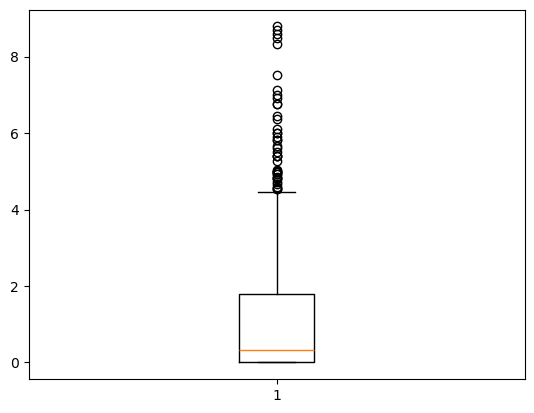

In [56]:
import matplotlib.pyplot as plt
plt.boxplot(df_no_outliers['Area diverted in hectares'])
plt.show()

In [57]:
df['Area diverted in hectares'].sum()

np.float64(3573.621)

In [58]:

df=df.drop(df[df['Area diverted in hectares']== 0].index)


In [59]:
df['Area diverted in hectares'].skew()

np.float64(8.01249578299439)

In [60]:
df['Area diverted in hectares'].describe()

count    490.000000
mean       7.293104
std       25.498773
min        0.001000
25%        0.035250
50%        0.697000
75%        3.712500
max      308.400000
Name: Area diverted in hectares, dtype: float64


**Which state has the highest number of forest diversion projects?**

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

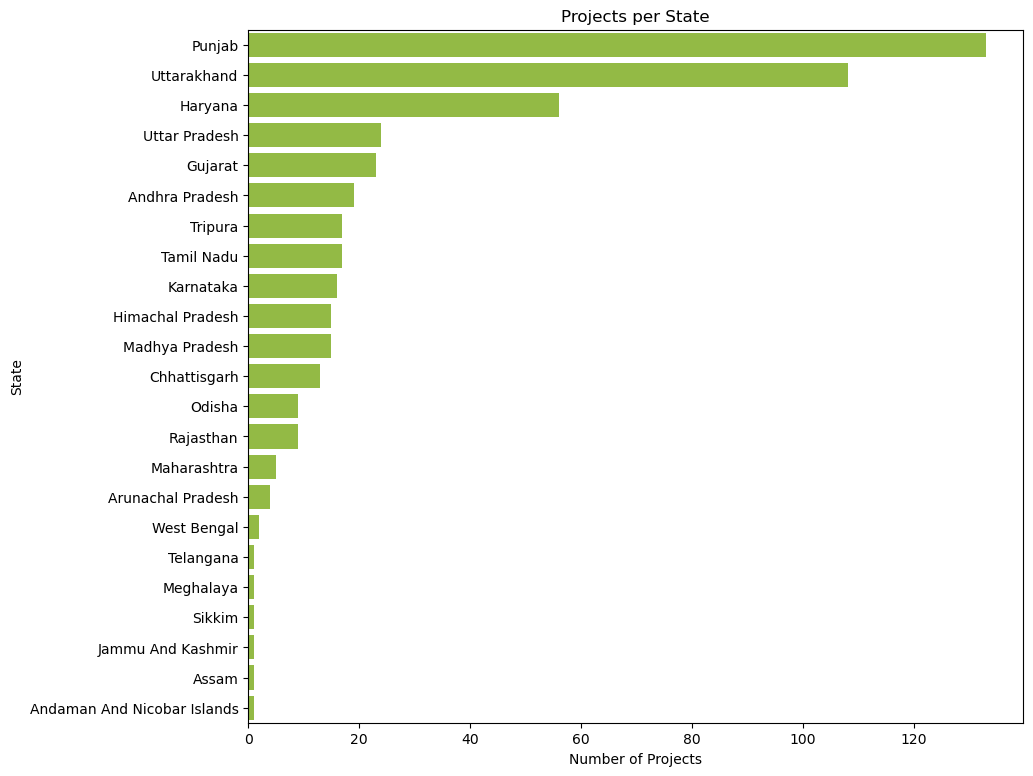

In [62]:
plt.figure(figsize=(10,9))
plt.title("Projects per State")

plt.xlabel("Number of Projects")
plt.ylabel("State")

sns.countplot(y='State name',data=df,order=df['State name'].value_counts().index,color='yellowgreen')
plt.show()

**Which state diverted the maximum forest land area?**

In [63]:
state_area =df.groupby('State name')['Area diverted in hectares'].sum()

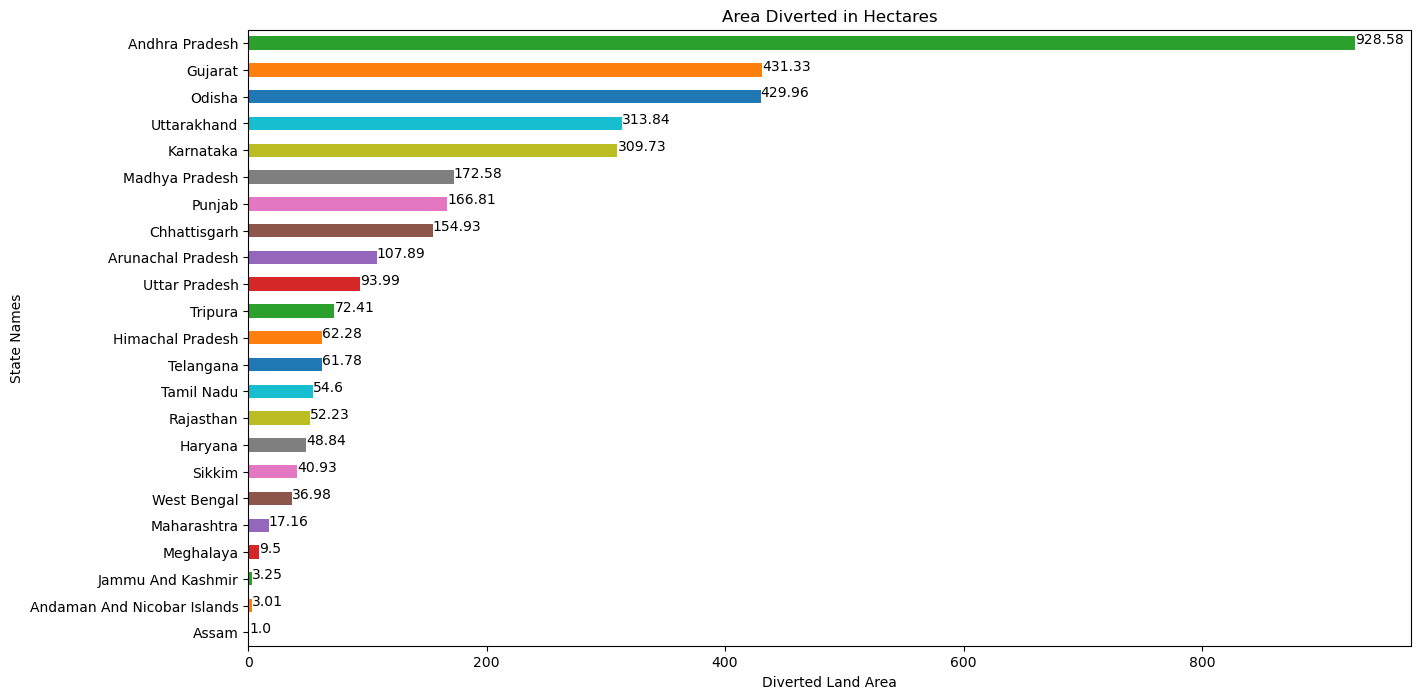

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,8))

colors = sns.color_palette()

ax=state_area.sort_values().plot(kind='barh', color=colors)
for index,value in enumerate(state_area.sort_values()):
    ax.text(value,index,round(value,2))

plt.title("Area Diverted in Hectares")
plt.xlabel("Diverted Land Area")
plt.ylabel("State Names")
plt.show()


**Top 10 states by diverted land area.**

In [65]:
Top_Ten_States=df.groupby('State name')['Area diverted in hectares'].sum().head(10)

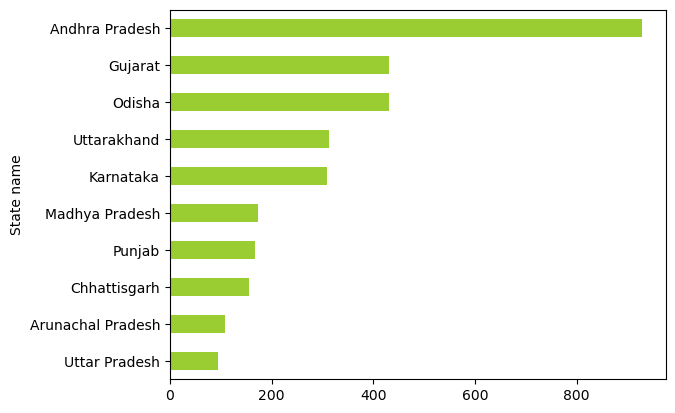

In [66]:
top10 = df.groupby('State name')['Area diverted in hectares'].sum().sort_values(ascending=False).head(10)

top10.plot(kind='barh',color='yellowgreen')
plt.gca().invert_yaxis()
plt.show()

**What is the distribution of diverted land area across projects?**

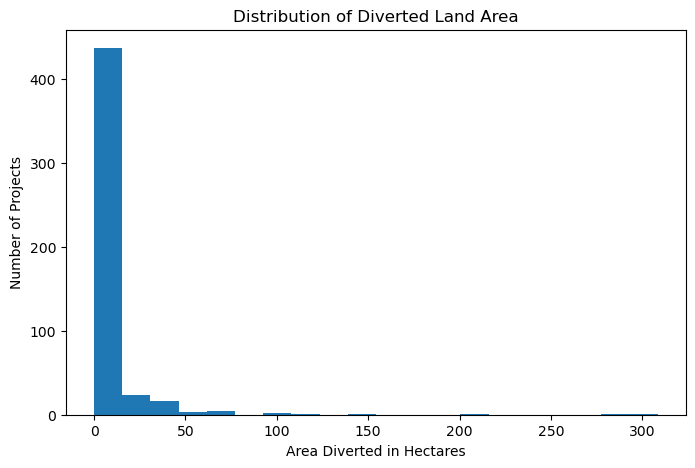

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['Area diverted in hectares'], bins=20)

plt.xlabel("Area Diverted in Hectares")
plt.ylabel("Number of Projects")
plt.title("Distribution of Diverted Land Area")

plt.show()

**Average diverted area per state.**

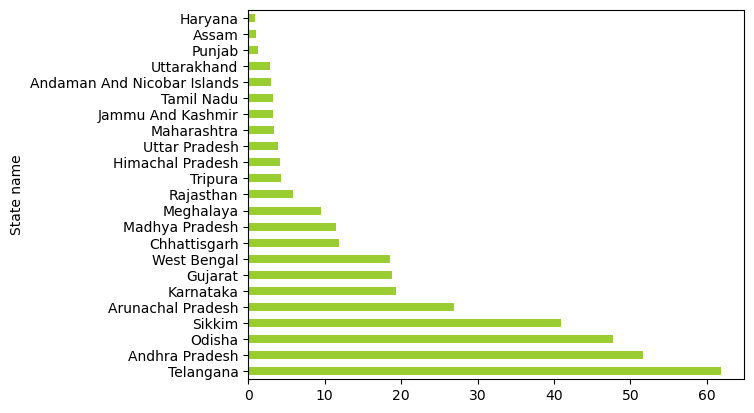

In [68]:
Avg_diverted_area=df.groupby('State name')['Area diverted in hectares'].mean().sort_values(ascending=True)

Avg_diverted_area.plot(kind='barh',color='yellowgreen')
plt.gca().invert_yaxis()
plt.show()

In [69]:
round(Avg_diverted_area,2)

State name
Haryana                         0.87
Assam                           1.00
Punjab                          1.25
Uttarakhand                     2.91
Andaman And Nicobar Islands     3.01
Tamil Nadu                      3.21
Jammu And Kashmir               3.26
Maharashtra                     3.43
Uttar Pradesh                   3.92
Himachal Pradesh                4.15
Tripura                         4.26
Rajasthan                       5.80
Meghalaya                       9.50
Madhya Pradesh                 11.51
Chhattisgarh                   11.92
West Bengal                    18.49
Gujarat                        18.75
Karnataka                      19.36
Arunachal Pradesh              26.97
Sikkim                         40.93
Odisha                         47.77
Andhra Pradesh                 51.59
Telangana                      61.78
Name: Area diverted in hectares, dtype: float64

**Which category diverts maximum land?**


In [70]:
df.columns

Index(['State name', 'Forest division name', 'Forest range name',
       'Forest conservation act project', 'Year of initiation of project',
       'Area diverted in hectares', 'Type of land', 'Updated on', 'Updated by',
       'Project type'],
      dtype='object')

In [71]:
df['Project type'].unique()

array(['road', 'irrigation', 'Hydro Electric Project',
       'petrol pump / retail outlet', 'ecotourism', 'mining', 'bridge',
       'transmission line', 'industry/factory', 'drilling', 'pipeline',
       'security infrastructure', 'building', 'water supply',
       'bus parking', 'stone crusher', 'rope way', 'resort/tourism',
       'railway', 'sewage/stp', 'telecommunication', 'others',
       'solar power', 'lpg godown', 'wind power', 'sewer line / drainage',
       'OPTICAL FIBRE CABALE'], dtype=object)

In [72]:
df.groupby('Project type')['Area diverted in hectares'].sum()

Project type
Hydro Electric Project           76.518
OPTICAL FIBRE CABALE              0.234
bridge                           13.706
building                         20.987
bus parking                       0.378
drilling                          8.223
ecotourism                        0.100
industry/factory                  0.442
irrigation                      297.448
lpg godown                        0.112
mining                         1307.206
others                            8.730
petrol pump / retail outlet       3.015
pipeline                         10.065
railway                         153.174
resort/tourism                    0.334
road                            887.574
rope way                          0.720
security infrastructure          53.018
sewage/stp                        0.318
sewer line / drainage             0.340
solar power                       0.002
stone crusher                     0.991
telecommunication                26.853
transmission line          

In [73]:
df['Type of land']=df['Type of land'].str.lower()

In [74]:
df['Type of land']=df['Type of land'].str.replace('petrol pump / retail outlet','petrol pump/retail outlet')

In [75]:
df['Type of land']=df['Type of land'].str.replace('sewer line / drainage','sewer line/drainage')

In [76]:
Project_Type_Analysis=df.groupby('Project type')['Area diverted in hectares'].sum().sort_values(ascending=False)


In [77]:
Project_Type_Analysis

Project type
mining                         1307.206
road                            887.574
transmission line               410.912
irrigation                      297.448
wind power                      189.634
railway                         153.174
water supply                    102.587
Hydro Electric Project           76.518
security infrastructure          53.018
telecommunication                26.853
building                         20.987
bridge                           13.706
pipeline                         10.065
others                            8.730
drilling                          8.223
petrol pump / retail outlet       3.015
stone crusher                     0.991
rope way                          0.720
industry/factory                  0.442
bus parking                       0.378
sewer line / drainage             0.340
resort/tourism                    0.334
sewage/stp                        0.318
OPTICAL FIBRE CABALE              0.234
lpg godown                 

In [78]:
df[df['Project type'].str.contains('road', case=False, na=False)]['Project type'].value_counts()

Project type
road    154
Name: count, dtype: int64

In [80]:
df['Area diverted in hectares'].describe(include='number').astype(int)

count    490
mean       7
std       25
min        0
25%        0
50%        0
75%        3
max      308
Name: Area diverted in hectares, dtype: int64

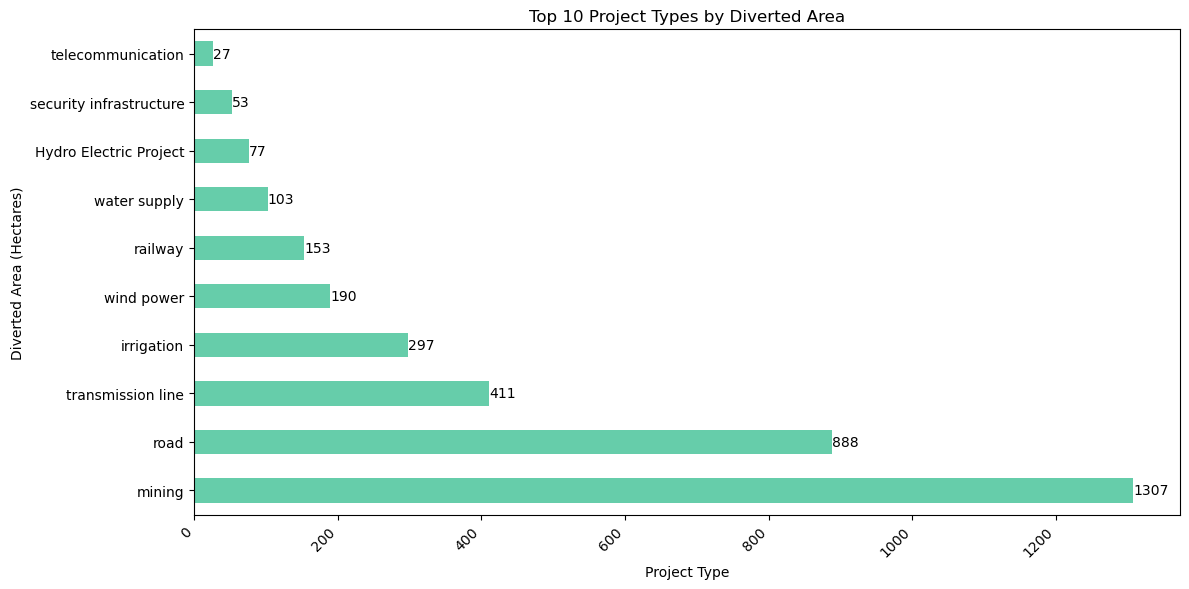

In [82]:
import matplotlib.pyplot as plt

project_area = (
    df.groupby('Project type')['Area diverted in hectares']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

ax = project_area.plot(
    kind='barh',
    figsize=(12,6),
    color='mediumaquamarine'
)

for c in ax.containers:
    ax.bar_label(c, fmt='%.0f')

plt.title('Top 10 Project Types by Diverted Area')
plt.xlabel('Project Type')
plt.ylabel('Diverted Area (Hectares)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**How does forest diversion vary across land types (RF, PF, Unclassified Forest)?**

In [83]:
df

,State name,Forest division name,Forest range name,Forest conservation act project,Year of initiation of project,Area diverted in hectares,Type of land,Updated on,Updated by,Project type
0,Uttarakhand,DFO Almora,"Ro Ranikhet ,Almora",kalika- dalmori motor road [6517],2006-01-01,4.860,reserved forest,2015-08-07,"DFO Almora , Almora",road
1,Madhya Pradesh,Balaghat North,South Lamta,upper ban ganga project (sanjay sarovar projec...,2002-01-01,19.619,reserved forest,2014-12-06,DFO Balaghat North,irrigation
2,Himachal Pradesh,Kullu,Bhutti,const of 4.50 mw sarwari-ii hydro electric pro...,2008-01-01,1.800,unclassified forest,2015-05-13,DFO Kullu,Hydro Electric Project
3,Madhya Pradesh,Balaghat North,South Lamta,upper ban ganga project (sanjay sarovar projec...,2002-01-01,4.727,reserved forest,2014-12-06,DFO Balaghat North,irrigation
4,Haryana,Sonipat,Sonipat,appraoch road to the retail outlet ksk of iocl...,2008-01-01,0.005,protected forest,2017-05-03,DFO Sonipat,petrol pump / retail outlet
...,...,...,...,...,...,...,...,...,...,...
495,Uttarakhand,DFO Lansdowne kotdwaar,"Ro Kotdi, Lansdowne",construction of reporting police outpost at sa...,1994-01-01,0.100,reserved forest,2015-09-09,"DFO Lansdowne, kotdwaar",security infrastructure
496,Himachal Pradesh,Ani at Luhari,Chowai,"chunadhar to paneo road, ani ft. divn.1305 [5883]",2019-01-01,3.357,unclassified forest,2016-10-13,DFO Ani at Luhari,road
497,Andhra Pradesh,Kakinada,Gokavaram,pushkar lift irrigation scheme [372],2006-01-01,1.000,reserved forest,2016-06-01,DFO Kakinada,irrigation
498,Punjab,Ludhiana,Ludhiana,diversion of 0.03568 ha.(instead of 0.011533 h...,2018-01-01,0.036,protected forest,2022-02-02,DFO Ludhiana,petrol pump / retail outlet


In [81]:
replace_dic={'unclassified revenue forest(with revenue department)':'revenue forest','proposed protected forest (proposed pf)':'proposed protected forest'
,            'ca land received under fca proposal':'Compensatory Afforestation Land',
            'govt. mangrove forest rf':'reserved forest',
            'govt. mangrove forest pf':'protected forest',
            'sec 4 ifa':'proposed protected forest',
            'unclassified revenue forest(with revenue department)':'revenue forest'}

In [82]:
df['Type of land']=df['Type of land'].replace(replace_dic).str.capitalize()

In [83]:
df['Type of land'].unique()

array(['Reserved forest', 'Unclassified forest', 'Protected forest',
       'Revenue forest', 'Proposed protected forest',
       'Compensatory afforestation land', 'Deemed forest', 'State forest',
       '261.31'], dtype=object)

In [84]:
df.drop(df[df['Type of land'] == '261.31'].index,inplace=True)

In [85]:
df['Type of land'] = df['Type of land'].replace(
    'Sec 4 ifa',
    'Proposed protected forest (proposed pf)'
)

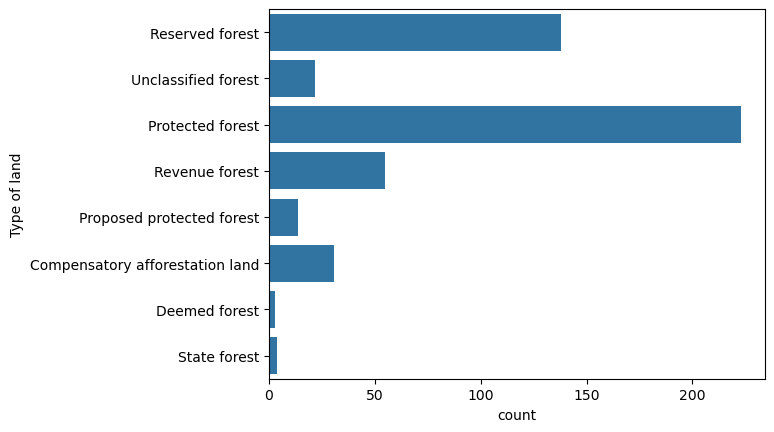

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.countplot(data=df, y='Type of land')

plt.show()



**Which year recorded the maximum number of projects?**

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 490 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   State name                       490 non-null    object        
 1   Forest division name             490 non-null    object        
 2   Forest range name                490 non-null    object        
 3   Forest conservation act project  490 non-null    object        
 4   Year of initiation of project    490 non-null    datetime64[ns]
 5   Area diverted in hectares        490 non-null    float64       
 6   Type of land                     490 non-null    object        
 7   Updated on                       490 non-null    datetime64[ns]
 8   Updated by                       490 non-null    object        
 9   Project type                     490 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 42.1+ KB


In [91]:
yearabove2020=df[df['Year of initiation of project'].dt.year>2000]

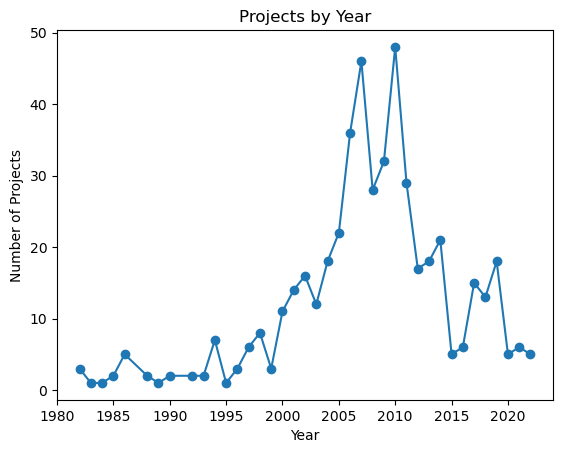

In [88]:
year_count = df['Year of initiation of project'].dt.year.value_counts().sort_index()

year_count.plot(kind='line', marker='o')

plt.xlabel("Year")
plt.ylabel("Number of Projects")
plt.title("Projects by Year")

plt.show()

In [89]:
df['Project Duration'] = (df['Updated on'] - df['Year of initiation of project'])

In [90]:
df['Project Duration']=(df['Project Duration'].dt.days/365).round(1)

In [91]:
df['Project Duration']

0       9.6
1      12.9
2       7.4
3      12.9
4       9.3
       ... 
495    21.7
496    -2.2
497    10.4
498     4.1
499    14.0
Name: Project Duration, Length: 490, dtype: float64

**What is the typical project completion duration?**

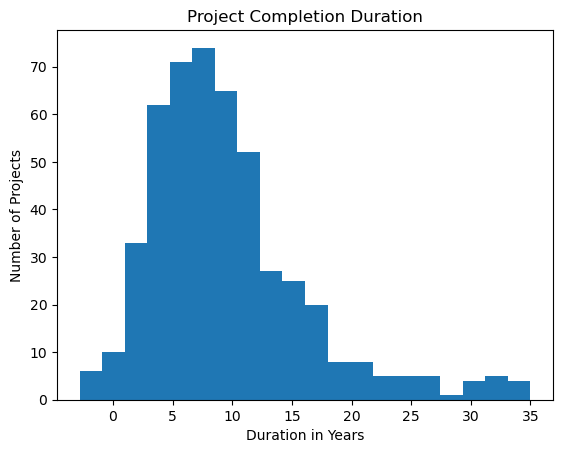

In [92]:
import matplotlib.pyplot as plt

plt.hist(df['Project Duration'], bins=20)

plt.xlabel("Duration in Years")
plt.ylabel("Number of Projects")
plt.title("Project Completion Duration")

plt.show()

In [93]:
df['Project type'].value_counts()

Project type
road                           154
petrol pump / retail outlet     93
transmission line               49
irrigation                      31
mining                          26
water supply                    23
Hydro Electric Project          18
building                        16
security infrastructure         14
bridge                          10
pipeline                        10
railway                         10
industry/factory                 6
drilling                         6
others                           4
wind power                       4
resort/tourism                   4
telecommunication                3
sewer line / drainage            1
lpg godown                       1
solar power                      1
rope way                         1
sewage/stp                       1
ecotourism                       1
stone crusher                    1
bus parking                      1
OPTICAL FIBRE CABALE             1
Name: count, dtype: int64

In [94]:
df.to_excel(r'C:\Users\DELL\Downloads\Forest_Diversion_Projects.xlsx', index=False)

Dashboard:
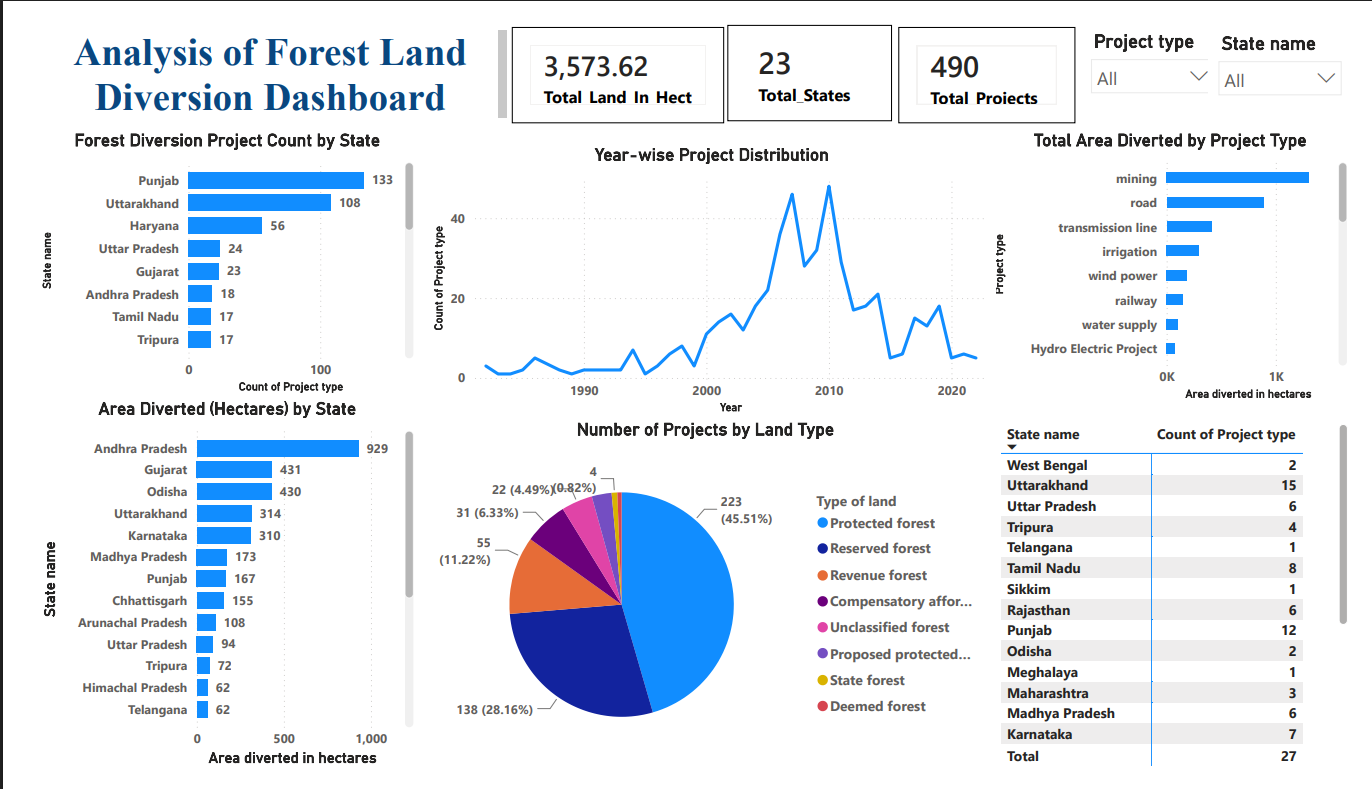


Documentation & Insights:

https://github.com/saranyasubramaniam9787-ship-it/Analysis-of-Forest-Land-Diversion-Dashboard/blob/main/Forest%20Land%20Diversion%20Dashboard_Insights.pdf